In [1]:
import numpy as np
import csv
import statistics
from scipy.spatial import distance
from collections import defaultdict
import os
import sys
module_path = '../train_output/'
if module_path not in sys.path:
    sys.path.append(module_path)

train_machine_feat_path = r'cifar10_train_feat_vit.csv'
train_prob_path =r'cifar10_train_prob_vit.csv'
test_machine_feat_path = r'cifar100_test_feat_vit.csv'
test_prob_path = r'cifar100_test_prob_vit.csv'
test_id_machine_feat_path = r'cifar10_test_feat_vit.csv'
test_id_prob_path = r'cifar10_test_prob_vit.csv'

def euclidian_distance(a, b):
    return np.linalg.norm(a-b)

def cosine_distance(a,b):
    return distance.cosine(a,b)

def kNeighborsDist(x_test, X_train, n_neighbors):

        # construct a list object containing the distance from x_test to each vector in X_train
        #point_dist_row = [euclidian_distance(x_test, x_train) for x_train in X_train]
        point_dist_row = [cosine_distance(x_test, x_train) for x_train in X_train]
        sqrd_point_dist_row = [val**2 for val in point_dist_row]
        # next two lines sort these distances from low to high and return (list_index, distance) tuples...
        # the sorted list of tuples is truncated to only the first "n_neighbors" elements
        enum_neigh = enumerate(sqrd_point_dist_row)
        sorted_neigh = sorted(enum_neigh, key=lambda x: x[1])[:n_neighbors]

        # grab the distance components from all the tuples in your k-NN list
        dist_list = [tup[1] for tup in sorted_neigh]

        # compute the total of these 5 distances
        totalDist = sum(dist_list)
        return totalDist
def make_dict():
    return defaultdict(make_dict)

def compute_delta(zNaught):
    # zNaught is the number of standard deviations at which we are willing to retain 95% of our original class probability
    # We get exactly 0.95 from the sigmoid function when x = 2.944438979
    # To get exacty this value when we are zNaught stdevs away, we do 2.944438979 = delta - zNaught
    # therefore, delta = zNaught + 2.944438979.
    # By subtracting our actual/realized zscore from delta, we will be computing our sigmoid value centered around zNaught stdevs being 0.95
    return zNaught + 2.944438979#23.02585#0.99999999    #13.8155 -> 0.999999 #4.595<- 0.99 #9.21024 <- 0.9999

def sigmoid(val):
    return 1/(1 + np.exp(-val, dtype=np.float64))

def zscore(x, mean, std):
    return (x-mean)/std

zFor95perc = 0
delta = compute_delta(zFor95perc)

In [2]:
import hnswlib
import numpy as np


def build_hnsw_index(X_train, ef_construction=200, M=32, ef_search=150):
    """
    Build an HNSW index for cosine-distance search.

    Parameters
    ----------
    X_train : np.ndarray, shape (N, d)
        Training embeddings / features.
    ef_construction : int
        Controls index build quality/speed tradeoff.
    M : int
        Number of bi-directional links created per node.
    ef_search : int
        Controls query-time accuracy/speed tradeoff.

    Returns
    -------
    index : hnswlib.Index
        Built HNSW index.
    """
    X_train = np.asarray(X_train, dtype=np.float32)
    dim = X_train.shape[1]

    index = hnswlib.Index(space="cosine", dim=dim)
    index.init_index(
        max_elements=X_train.shape[0],
        ef_construction=ef_construction,
        M=M,
    )
    index.add_items(X_train)
    index.set_ef(ef_search)

    return index


def kneighbors_dist_hnsw(X_query, index, n_neighbors, assume_self=False):
    """
    Compute sum of squared distances to the k nearest neighbors.

    Parameters
    ----------
    X_query : np.ndarray
        Query array of shape (d,) for a single query or (N, d) for a batch.
    index : hnswlib.Index
        Built HNSW index.
    n_neighbors : int
        Number of neighbors to use in the score.
    assume_self : bool
        If True, assumes each query point is also in the index and removes
        the nearest match (self-match). Use this for train-on-train queries.
        If False, keeps the top-k returned neighbors. Use this for test/OOD queries.

    Returns
    -------
    scores : float or np.ndarray
        If input was shape (d,), returns a scalar.
        If input was shape (N, d), returns shape (N,).
    """
    X_query = np.asarray(X_query, dtype=np.float32)
    single_input = (X_query.ndim == 1)

    if single_input:
        X_query = X_query.reshape(1, -1)

    k_search = n_neighbors + 1 if assume_self else n_neighbors

    labels, distances = index.knn_query(X_query, k=k_search)
    distances = np.asarray(distances)

    # For train-on-train search, remove the nearest one assuming it is self.
    if assume_self:
        distances = np.sort(distances, axis=1)[:, 1:n_neighbors + 1]
    else:
        distances = np.sort(distances, axis=1)[:, :n_neighbors]

    scores = np.sum(distances ** 2, axis=1)

    if single_input:
        return float(scores[0])
    return scores

In [3]:
ID_Class = 4
All_Class = 104
Dataset_Name = 'CIFAR_PlUS10'
number_of_neighbors = 11 #it's range(1,11)

In [4]:
#TODO SUBSET 10 and 50 out of 100 CIFAR100 Classes (That's the +10 and +50 Stuff)

In [5]:
trueClass = []
predClass = []
data_p = [l.strip().split(",") for l in open(train_prob_path).readlines()]
for i in range(len(data_p)):
    thisClass = int(float(data_p[i][0]))
    thisVec = data_p[i][1:]

    for j in range(len(thisVec)):
        thisVec[j] = float(thisVec[j])
    thisVec = np.array(thisVec)
    maxArg = int(np.argmax(thisVec))

    trueClass.append(thisClass)
    predClass.append(maxArg)
data = [l.strip().split(",") for l in open(train_machine_feat_path).readlines()]
train_feature_vectors = {}
correct_count =0
for thisClass in range(ID_Class):          ###############change for mp 15
    train_feature_vectors[thisClass] = []
for i in range(len(data)):
    thisClass = int(float(data[i][0]))
    thisVec = data[i][1:]

    for j in range(len(thisVec)):
        thisVec[j] = float(thisVec[j])
    thisVec = np.array(thisVec)

    # Only add this one in if it was correctly predicted (predClass == trueClass)
    if (trueClass[i] == predClass[i]):
        train_feature_vectors[thisClass].append(thisVec)
        correct_count+=1
print(correct_count/len(data_p))

0.9988958206812787


In [6]:
len(data_p)

18113

In [7]:
data_p[0]

['3.000000000000000000e+00',
 '1.216480508446693420e-03',
 '1.356987515464425087e-03',
 '1.910142018459737301e-03',
 '9.955163598060607910e-01']

In [8]:
len(train_feature_vectors[3])

4550

In [9]:
train_feature_vectors.keys()

dict_keys([0, 1, 2, 3])

In [10]:
# Compute empirical distribution of Dij2 values for each class
for neighbor in range(1,number_of_neighbors):
    Dij2 = defaultdict(list)#{}
    print('\nWorking on:')
    for cls in train_feature_vectors:
        X_train = np.array(train_feature_vectors[cls], dtype=np.float32)
        index = build_hnsw_index(X_train)

        Dij2_cls = kneighbors_dist_hnsw(
            X_query=X_train,
            index=index,
            n_neighbors=neighbor,
            assume_self=True
        )

        Dij2[cls].extend(Dij2_cls.tolist())
    alpha = 0.1
    confidence = 1.0-alpha
    threshold = {}
    for cls in Dij2:
        thisMin = min(Dij2[cls])
        thisMax = max(Dij2[cls])
        this90thPerctl = thisMin + confidence*(thisMax-thisMin)
        threshold[cls] = this90thPerctl

    with open(f'membership_threshold_{Dataset_Name}_tune_neighbor_{neighbor}_cosine_appx.csv', 'w') as csvfile:
        writer = csv.writer(csvfile)
        for cls in threshold:
            row = [cls, threshold[cls]]
            writer.writerow(row)
    aveDij2ByClass = {}
    stdDij2ByClass = {}
    for cls in Dij2:
        thisAve = statistics.mean(Dij2[cls])
        thisStd = statistics.stdev(Dij2[cls])

    with open(f'mean_and_std_distance_train_to_kNearestTrain_{Dataset_Name}_tune_neighbor_{neighbor}_cosine_appx.csv', 'w') as csvfile:
        writer = csv.writer(csvfile)
        for cls in Dij2:
            thisAve = statistics.mean(Dij2[cls])
            thisStd = statistics.stdev(Dij2[cls])
            row = [cls, thisAve, thisStd]
            writer.writerow(row)

    print('\nDone')


Working on:

Done

Working on:

Done

Working on:

Done

Working on:

Done

Working on:

Done

Working on:

Done

Working on:

Done

Working on:

Done

Working on:

Done

Working on:

Done


In [11]:
#Step 2

In [14]:
# Load testset feature vectors
print('\nLoading test data...')
data = [l.strip().split(",") for l in (open(test_id_machine_feat_path).readlines() + open(test_machine_feat_path).readlines())]
test_feature_vectors = {}
for i in range(len(data)):
    thisClass = int(float(data[i][0]))
    thisVec = data[i][1:]
    for j in range(len(thisVec)):
        thisVec[j] = float(thisVec[j])
    test_feature_vectors[i] = np.array(thisVec)



# Compute distances from each test instance to the k-Nearest neighbors in each of the training classes
print('\nComputing distance from test instances to k-Nearset train instances of every class...')
for neighbor in range(1,number_of_neighbors):

    Dij2 = defaultdict(dict)

    # stack all test vectors once
    test_ids = list(test_feature_vectors.keys())
    X_test = np.array([test_feature_vectors[i] for i in test_ids], dtype=np.float32)

    for cls, feats in train_feature_vectors.items():
        # build index ONCE per class
        X_train = np.asarray(feats, dtype=np.float32)
        index = build_hnsw_index(X_train)

        # batch query ALL test points
        Dij2_cls = kneighbors_dist_hnsw(
            X_query=X_test,
            index=index,
            n_neighbors=neighbor,
            assume_self=False   # important: test != train
        )

        # assign results back
        for i, inst in enumerate(test_ids):
            Dij2[inst][cls] = float(Dij2_cls[i])

    print('\nWriting results')
    with open(f'distance_testInst_to_kNearestTrain_{Dataset_Name}_tune_neighbor_{neighbor}_cosine_appx.csv', 'w') as csvfile:
        writer = csv.writer(csvfile)
        rowZero = [' ']
        for clsID in range(ID_Class): ########change
            rowZero.append(clsID)
        writer.writerow(rowZero)
        for i in range(len(data)):
            thisClass = data[i][0]
            if i >= test_id_count: #cifar100 also starts from 0
                thisClass = float(thisClass)+4
            row = [str(thisClass)]
            for clsID in range(ID_Class): ############change
                row.append(Dij2[i][clsID])
            writer.writerow(row)

    print('\nDone')


Loading test data...

Computing distance from test instances to k-Nearset train instances of every class...

Writing results

Done

Writing results

Done

Writing results

Done

Writing results

Done

Writing results

Done

Writing results

Done

Writing results

Done

Writing results

Done

Writing results

Done

Writing results

Done


In [15]:
#Step 3

In [18]:
data = [l.strip().split(',') for l in (open(test_id_prob_path).readlines() + open(test_prob_path).readlines())]
trueClass = [int(float(data[i][0])) + (4 if i >= test_id_count else 0) for i in range(len(data))]
P0 = defaultdict(make_dict)
for i in range(len(data)):
    for j in range(1,len(data[i])): #because in data it's label + prob
        thisClass = j-1 #
        #print(thisClass)
        #break

        P0[i][thisClass] = float(data[i][j]) 
        #break
    #break

In [19]:
for neighbor in range(1,number_of_neighbors):
    data = [l.strip().split(',') for l in open(f'distance_testInst_to_kNearestTrain_{Dataset_Name}_tune_neighbor_{neighbor}_cosine_appx.csv').readlines()]
    D_i_c = defaultdict(make_dict)
    for i in range(1,len(data)):
        thisInstance = i-1
        for j in range(1,len(data[i])):
            thisClass = j-1
            D_i_c[thisInstance][thisClass] = float(data[i][j])
    data = [l.strip().split(',') for l in open(f'mean_and_std_distance_train_to_kNearestTrain_{Dataset_Name}_tune_neighbor_{neighbor}_cosine_appx.csv').readlines()]
    Dbar_c, STD_c = {}, {}
    for i in range(0,len(data)):
        thisClass = int(data[i][0])
        Dbar_c[thisClass] = float(data[i][1])
        STD_c[thisClass] = float(data[i][2])
    Pstar = defaultdict(make_dict)
    for inst in P0:
        #print(inst)
        for cls in P0[inst]:
            # print(inst, cls, (delta-zscore(D_i_c[inst][cls], Dbar_c[cls], STD_c[cls])))
            Pstar[inst][cls] = P0[inst][cls]*sigmoid(delta-zscore(D_i_c[inst][cls], Dbar_c[cls], STD_c[cls]))#2*inst+1
    with open(f'test_class_confidence_{Dataset_Name}_tune_neighbor_{neighbor}_cosine_appx.csv', 'w') as csvfile:
        writer = csv.writer(csvfile)
        rowZero = [' ']
        for cls in range(ID_Class): ##########change
            rowZero.append(cls)
        rowZero.append('OpenSet')
        writer.writerow(rowZero)

        for inst in range(len(trueClass)):
            totalProb = 0.0
            row = [trueClass[inst]]
            for cls in range(ID_Class): ###########change
                row.append(Pstar[inst][cls])
                totalProb += Pstar[inst][cls]
            openSetProb = 1.0 - totalProb
            if openSetProb < 0:
                openSetProb = 0.0
            row.append(openSetProb)
            writer.writerow(row)

In [21]:
#Step 6

In [22]:
c= [i for i in range(All_Class)]
m = dict()
for i in c:
    m[i]=i
classList = c
classMap = m

In [23]:
all_f = {}
for neighbor in range(1, number_of_neighbors):
    data = [l.strip().split(',') for l in open(f'test_class_confidence_{Dataset_Name}_tune_neighbor_{neighbor}_cosine_appx.csv').readlines()]
    #data = data[::2]
    truePos = {c: 0.0 for c in classList}
    falsePos = {c: 0.0 for c in classList}
    falseNeg = {c: 0.0 for c in classList}

    # totalByClass = {c: 0.0 for c in classList}
    # top1CorrectByClass = {c: 0.0 for c in classList}
    # top2CorrectByClass = {c: 0.0 for c in classList}
    for i in range(1,len(data)):
        trueClass = int(data[i][0])
        theseProbs = data[i][1:]
        for j in range(len(theseProbs)):
            theseProbs[j] = float(theseProbs[j])
        theseProbs = np.array(theseProbs)

        # totalByClass[trueClass] += 1

        # Top-1 accuracy
        predClass = np.argmax(theseProbs) 
        if trueClass > (ID_Class-1):
            if predClass == ID_Class:
                truePos[trueClass] += 1
            else:
                falseNeg[trueClass] += 1
                falsePos[predClass] += 1
        else:
            if predClass == trueClass:
                truePos[trueClass] += 1
            else:
                falseNeg[trueClass] += 1
                falsePos[predClass] += 1
    precision = {c: 0.0 for c in classList}
    recall = {c: 0.0 for c in classList}
    fmeasure = {c: 0.0 for c in classList}
    with open(f'top1fmeasure_confidence_{Dataset_Name}_tune_neighbor_{neighbor}_cosine_appx.csv', 'w') as csvfile:
        writer = csv.writer(csvfile)
        rowZero = [' '] + [classMap[classList[i]] for i in range(len(classList))]
        writer.writerow(rowZero)
        
        rowTwo = ['fmeasure']
        for c in classList:
            fmeasure[c] = truePos[c]/(truePos[c] + 0.5*(falsePos[c] + falseNeg[c])) 
            rowTwo.append(fmeasure[c])
        all_f[neighbor] = rowTwo
        writer.writerow(rowTwo)

In [24]:
#all_f

In [25]:
len(all_f[1])

105

In [26]:
avg_f = []
for key, value in all_f.items():
    temp = value[1:]
    avg = np.mean(temp)
    avg_f.append(avg)
avg_f

[0.8668555942361805,
 0.8637976055101646,
 0.8599426645467022,
 0.8593417735502945,
 0.8580601953557185,
 0.8574358623447692,
 0.8576675015241672,
 0.8575024543116254,
 0.8570270754320648,
 0.8569992158349534]

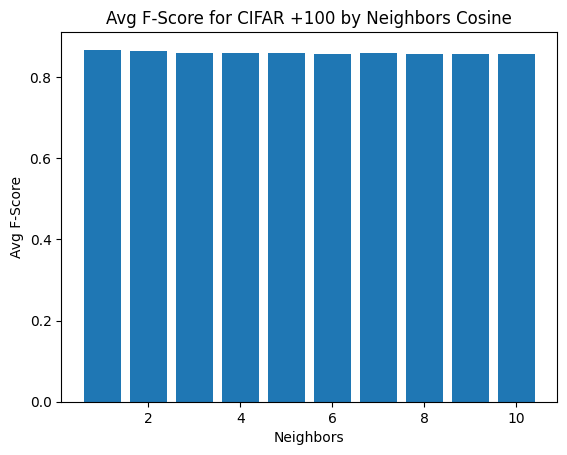

In [27]:
import matplotlib.pyplot as plt

# Example array of 10 values
y_values = avg_f

# X-axis values from 1 to 10
x_values = list(range(1, 11))

# Create the bar plot
plt.bar(x_values, y_values)

# Add labels and title
plt.xlabel('Neighbors')
plt.ylabel('Avg F-Score')
plt.title('Avg F-Score for CIFAR +100 by Neighbors Cosine')

# Show the plot
plt.show()


In [28]:
all_f[np.argmax(avg_f)+1]

['fmeasure',
 0.896551724137931,
 0.9100138440239963,
 0.8591800356506238,
 0.6176656151419558,
 0.7168458781362007,
 0.9949748743718593,
 0.9583333333333334,
 0.7421383647798742,
 0.717948717948718,
 0.9949748743718593,
 0.9417989417989417,
 0.9417989417989417,
 0.9949748743718593,
 1.0,
 0.98989898989899,
 0.9743589743589743,
 0.8888888888888888,
 0.5815602836879432,
 0.8950276243093923,
 0.8304093567251462,
 1.0,
 0.9949748743718593,
 0.9583333333333334,
 0.9010989010989011,
 0.98989898989899,
 0.9417989417989417,
 1.0,
 0.9637305699481865,
 0.98989898989899,
 0.9690721649484536,
 0.93048128342246,
 0.8764044943820225,
 0.9949748743718593,
 0.8764044943820225,
 0.88268156424581,
 0.9010989010989011,
 0.9361702127659575,
 0.9847715736040609,
 0.31932773109243695,
 0.9847715736040609,
 0.21428571428571427,
 0.9583333333333334,
 0.6928104575163399,
 0.9949748743718593,
 0.9847715736040609,
 0.9417989417989417,
 0.37398373983739835,
 0.4732824427480916,
 0.9528795811518325,
 0.947368421

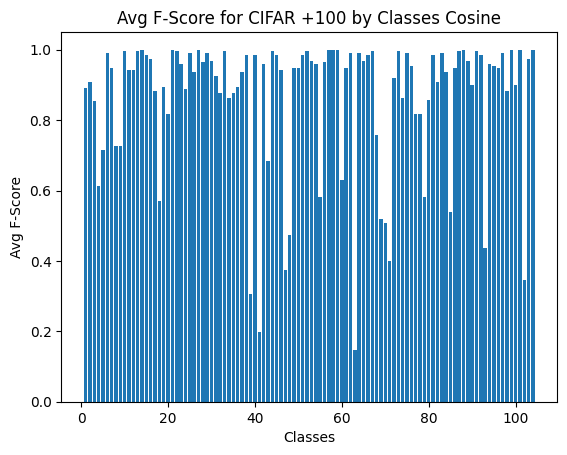

In [29]:
# Example array of 10 values
y_values = all_f[2][1:]
# X-axis values from 1 to 10
x_values = list(range(1, All_Class+1))

# Create the bar plot
plt.bar(x_values, y_values)

# Add labels and title
plt.xlabel('Classes')
plt.ylabel('Avg F-Score')
plt.title('Avg F-Score for CIFAR +100 by Classes Cosine')

# Show the plot
plt.show()

In [30]:
len(y_values)

104

In [31]:
import numpy as np

# y_values: length 104 (first 4 = known, rest = unknown)
y_values = np.array(y_values)

known_f = y_values[:4]
unknown_f = y_values[4:]

def sample_bucketed_stats(known_f, unknown_f, subset_size, n_samples=200, seed=42):
    rng = np.random.default_rng(seed)
    
    overall_means = []
    
    for _ in range(n_samples):
        # sample unknown classes
        subset = rng.choice(unknown_f, size=subset_size, replace=False)
        
        # aggregate unknowns into ONE bucket
        unknown_bucket = np.mean(subset)
        
        # combine: 4 known + 1 unknown bucket
        combined = np.concatenate([known_f, [unknown_bucket]])
        
        # average across (known classes + 1 unknown bucket)
        overall_means.append(np.mean(combined))
    
    overall_means = np.array(overall_means)
    
    return {
        "mean": overall_means.mean(),
        "std": overall_means.std(ddof=1),
        "all_samples": overall_means
    }

# CIFAR+10 (unknown bucket built from 10 sampled classes)
stats_10 = sample_bucketed_stats(known_f, unknown_f, subset_size=10)

# CIFAR+50
stats_50 = sample_bucketed_stats(known_f, unknown_f, subset_size=50)

print("CIFAR+10:", stats_10["mean"], stats_10["std"])
print("CIFAR+50:", stats_50["mean"], stats_50["std"])

CIFAR+10: 0.8270696027741227 0.012269461749946383
CIFAR+50: 0.8269530420584396 0.003883458343079703


In [32]:
import numpy as np

# y_values: array of length 104 (first 4 = known, rest = unknown)
y_values = np.array(y_values)

# only unknown classes (indices 4 to 103 → total 100 classes)
unknown_f = y_values[4:]

def sample_subset_stats(unknown_f, subset_size, n_samples=200, seed=42):
    rng = np.random.default_rng(seed)
    
    subset_means = []
    
    for _ in range(n_samples):
        # sample WITHOUT replacement
        subset = rng.choice(unknown_f, size=subset_size, replace=False)
        subset_means.append(np.mean(subset))
    
    subset_means = np.array(subset_means)
    
    return {
        "mean": subset_means.mean(),
        "std": subset_means.std(ddof=1),
        "all_samples": subset_means  # optional, for plotting
    }

# CIFAR+10
stats_10 = sample_subset_stats(unknown_f, subset_size=10, n_samples=200)

# CIFAR+50
stats_50 = sample_subset_stats(unknown_f, subset_size=50, n_samples=200)

print("CIFAR+10:", stats_10["mean"], stats_10["std"])
print("CIFAR+50:", stats_50["mean"], stats_50["std"])

CIFAR+10: 0.8639837802757873 0.061347308749731905
CIFAR+50: 0.8634009766973716 0.01941729171539852


In [33]:
# 95% interval
low_10, high_10 = np.percentile(stats_10["all_samples"], [2.5, 97.5])
low_50, high_50 = np.percentile(stats_50["all_samples"], [2.5, 97.5])

In [34]:
print(f'+10 low:{low_10}, high: {high_10}')
print(f'+50 low:{low_50}, high: {high_50}')

+10 low:0.7360740313167536, high: 0.9687872275601841
+50 low:0.8266376426825249, high: 0.9013883603983728


In [35]:
################Paper Stuff

In [36]:
import numpy as np

# y_values: length 104 (first 4 = known, rest = unknown)
y_values = np.array(y_values)

known_f = y_values[:4]
unknown_f = y_values[4:]

def sample_stats_with_bucket(known_f, unknown_f, subset_size, n_samples=200, seed=42):
    rng = np.random.default_rng(seed)

    known_mean = np.mean(known_f)

    unknown_sample_means = []
    bucketed_means = []

    for _ in range(n_samples):
        sampled_unknowns = rng.choice(unknown_f, size=subset_size, replace=False)

        unknown_mean = np.mean(sampled_unknowns)

        # 4 known classes + 1 unknown bucket
        bucketed = np.concatenate([known_f, [unknown_mean]])
        bucketed_mean = np.mean(bucketed)

        unknown_sample_means.append(unknown_mean)
        bucketed_means.append(bucketed_mean)

    unknown_sample_means = np.array(unknown_sample_means)
    bucketed_means = np.array(bucketed_means)

    return {
        "known_mean": known_mean,

        "unknown_mean": unknown_sample_means.mean(),
        "unknown_std": unknown_sample_means.std(ddof=1),

        "bucketed_mean": bucketed_means.mean(),
        "bucketed_var": bucketed_means.std(ddof=1),

        "unknown_all_samples": unknown_sample_means,
        "bucketed_all_samples": bucketed_means,
    }

stats_10 = sample_stats_with_bucket(
    known_f, unknown_f, subset_size=10, n_samples=200, seed=42
)

stats_50 = sample_stats_with_bucket(
    known_f, unknown_f, subset_size=50, n_samples=200, seed=42
)

print("CIFAR+10")
print("Known mean:", stats_10["known_mean"])
print("Unknown mean:", stats_10["unknown_mean"])
print("Unknown std:", stats_10["unknown_std"])
print("Bucketed mean:", stats_10["bucketed_mean"])
print("Bucketed std:", stats_10["bucketed_var"])

print("\nCIFAR+50")
print("Known mean:", stats_50["known_mean"])
print("Unknown mean:", stats_50["unknown_mean"])
print("Unknown std:", stats_50["unknown_std"])
print("Bucketed mean:", stats_50["bucketed_mean"])
print("Bucketed std:", stats_50["bucketed_var"])

CIFAR+10
Known mean: 0.8178410583987066
Unknown mean: 0.8639837802757873
Unknown std: 0.061347308749731905
Bucketed mean: 0.8270696027741227
Bucketed std: 0.012269461749946383

CIFAR+50
Known mean: 0.8178410583987066
Unknown mean: 0.8634009766973716
Unknown std: 0.01941729171539852
Bucketed mean: 0.8269530420584396
Bucketed std: 0.003883458343079703
